# Exploratory Data Analysis (EDA)

## Objective

Analyze the cleaned retail sales dataset to identify business insights,
discover trends, and answer key business questions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("../data/cleaned/sample_-_superstore.xlsx")

# Business Metrics (KPIs)

In [4]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
average_discount = df["discount"].mean()
average_profit_margin = df["profit_margin"].mean()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Discount: {average_discount:.2%}")
print(f"Average Profit Margin: {average_profit_margin:.2%}")

Total Sales: 2,326,534.35
Total Profit: 292,296.81
Total Orders: 5,111
Average Discount: 15.54%
Average Profit Margin: 12.22%


# Time Analysis
## Yearly Sales Trend

In [5]:
yearly_sales = (
    df.groupby("order_year", as_index=False)["sales"]
      .sum()
)

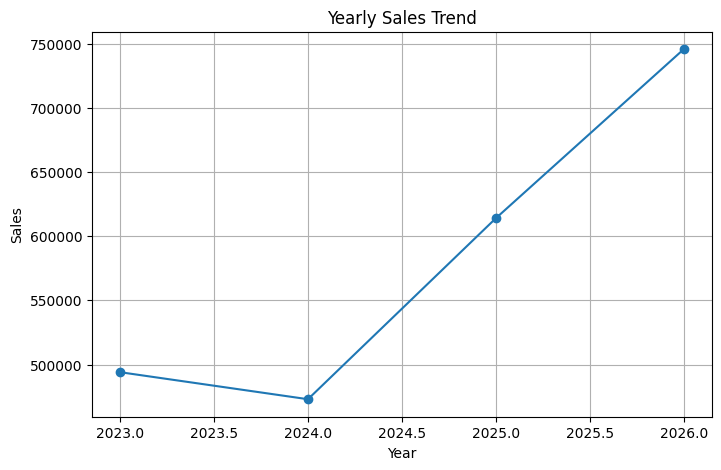

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_sales["order_year"],
    yearly_sales["sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Observations

- Sales declined from 2023 to 2024, with 2024 recording the lowest annual sales during the observed period.
- Sales recovered strongly after 2024 and increased consistently through 2025 and 2026.

## Business Interpretation

- The business experienced a temporary slowdown in 2024 but recovered in subsequent years.
- The sustained growth after 2024 suggests that the company's sales performance improved over time.

## Recommendation

- Investigate the factors contributing to the decline in 2024 to reduce the likelihood of similar downturns.
- Analyze the strategies associated with the growth period after 2024 and determine whether they can be continued or expanded.

----------------------------------------------------------------------------------------------------------------------------------------------------

# Monthly Sales Analysis

## Objective

Analyze monthly sales performance to identify seasonal patterns and peak sales periods.

In [7]:
df.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country_region',
 'city',
 'state_province',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'order_month',
 'order_year',
 'order_day',
 'shipping_days',
 'profit_margin',
 'is_loss',
 'order_month_num']

In [8]:
monthly_sales = (
    df.groupby(
        ["order_month_num", "order_month"],
        as_index=False
    )["sales"].sum()
)

In [9]:
monthly_sales = monthly_sales.sort_values("order_month_num")

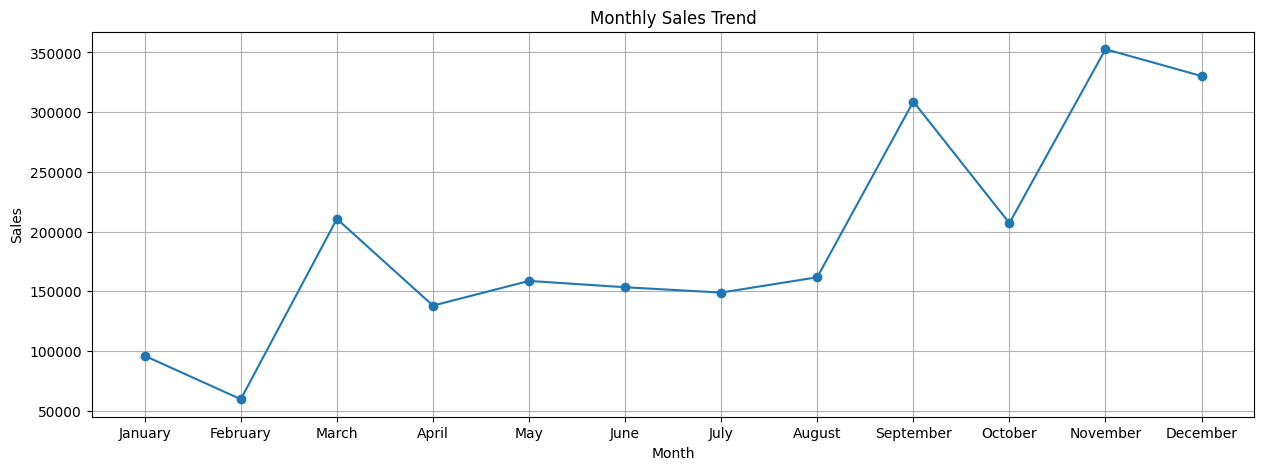

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [11]:
monthly_sales.sort_values("sales", ascending=False) #verifying the above plot is correct

,order_month_num,order_month,sales
10,11,November,352665.9910
11,12,December,330218.1755
8,9,September,308883.6697
2,3,March,210672.0868
9,10,October,207126.2567
7,8,August,161821.9150
4,5,May,158765.0337
5,6,June,153459.9973
6,7,July,149001.7130
3,4,April,138098.7486


# Key Observations
* November recorded the highest total sales across all months.
* February recorded the lowest total sales.
* Sales generally increased during the final quarter (October–December).

# Business Interpretation
* The business experiences stronger sales toward the end of the year, indicating possible seasonal demand.
* Early-year sales are comparatively weaker, suggesting opportunities to stimulate demand during that period.

# Recommendations
* Plan inventory and staffing to support increased demand during the final quarter.
* Introduce targeted promotions or marketing campaigns during lower-performing months to improve sales consistency.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Regional Performance

## Objective

Evaluate sales and profitability across different regions to identify high-performing and underperforming markets.

In [12]:
region_summary = (
    df.groupby("region", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          average_profit_margin=("profit_margin", "mean")
      )
)

region_summary = region_summary.sort_values(
    "total_sales",
    ascending=False
)

region_summary

,region,total_sales,total_profit,average_profit_margin
3,West,739813.6085,110798.8170,0.220214
1,East,691828.1680,94883.2603,0.170532
0,Central,503170.6728,39865.3070,-0.104745
2,South,391721.9050,46749.4303,0.163519


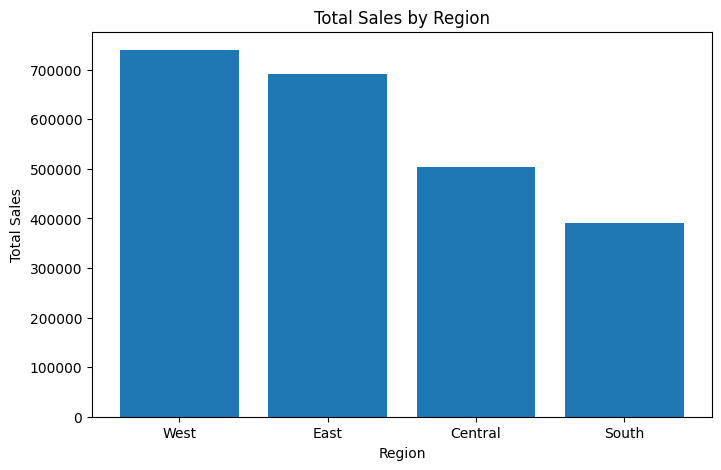

In [13]:
plt.figure(figsize=(8,5)) # Create a bar chart to visualize total sales by region

plt.bar(
    region_summary["region"],
    region_summary["total_sales"]
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

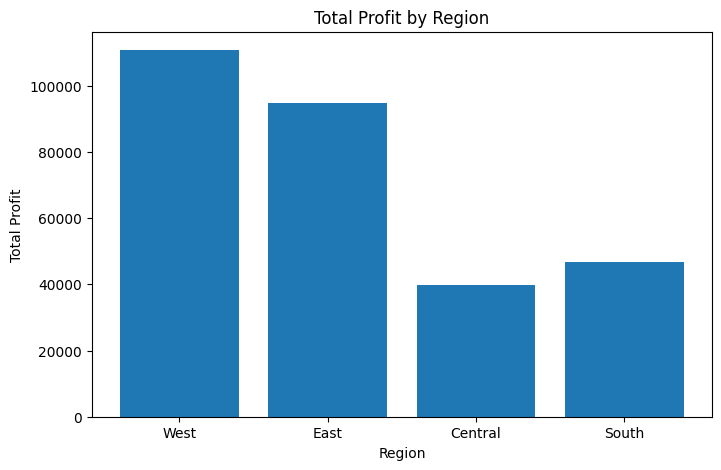

In [14]:
plt.figure(figsize=(8,5)) # Create a bar chart to visualize total profit by region

plt.bar(
    region_summary["region"],
    region_summary["total_profit"]
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

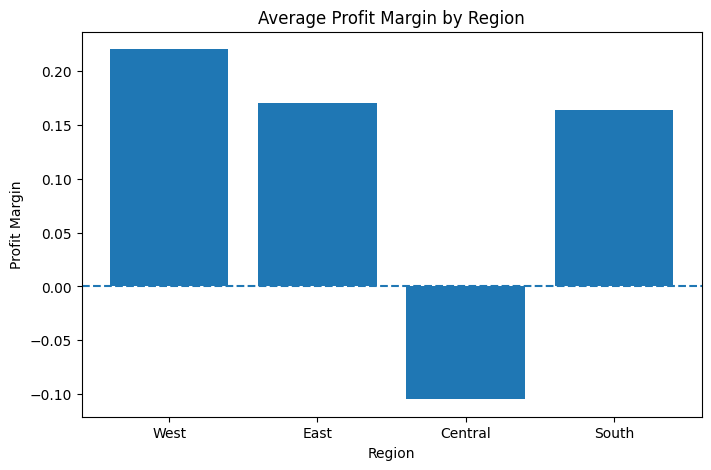

In [15]:
plt.figure(figsize=(8,5)) # Create a bar chart to visualize average profit margin by region

plt.bar(
    region_summary["region"],
    region_summary["average_profit_margin"]
)

plt.title("Average Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin")

plt.axhline(0, linestyle="--")

plt.show()

## Key Observations
* The West region generated the highest sales and profit.
* The East region also performed well with a healthy positive profit margin.
* The Central region recorded a negative average profit margin despite generating substantial sales.
* The South region delivered moderate sales and profitability.

## Business Interpretation
* Higher sales do not always translate into higher profitability, as demonstrated by the Central region.
* The West region appears to balance both revenue generation and profitability effectively.
* The Central region requires further investigation to determine whether discounts, product mix, or operational factors are reducing profitability.

## Recommendations
* Investigate the drivers of losses in the Central region before expanding sales efforts.
* Study successful practices from the West region and evaluate whether they can be replicated elsewhere.
* Prioritize improving profitability rather than focusing solely on increasing sales.


-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Product Analysis

## Sales by Category

### Objective

Analyze how total sales are distributed across different product categories to identify the company's primary revenue sources.

In [16]:
sales_by_category = (
    df.groupby("category", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)

sales_by_category

,category,sales
2,Technology,839893.2790
0,Furniture,754747.7613
1,Office Supplies,731893.3140


In [17]:
sales_by_category["sales_pct"] = (
    sales_by_category["sales"]
    / sales_by_category["sales"].sum()
    * 100
)

sales_by_category

,category,sales,sales_pct
2,Technology,839893.2790,36.100618
0,Furniture,754747.7613,32.440860
1,Office Supplies,731893.3140,31.458522


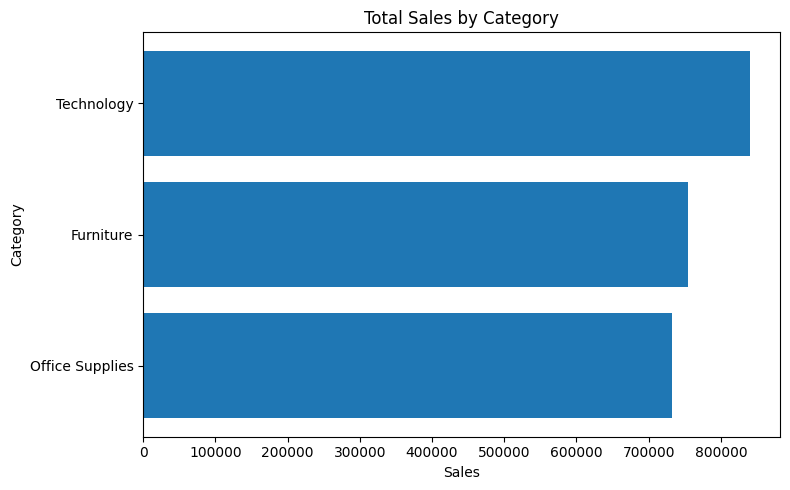

In [18]:
plt.figure(figsize=(8, 5)) # Create a horizontal bar chart to visualize total sales by category

plt.barh(
    sales_by_category["category"],
    sales_by_category["sales"]
)

plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Data Summary

The dataset contains sales across three product categories. Total sales were aggregated for each category to compare their contribution to overall revenue.

### Key Observations

- Technology generated the highest sales. 
- Furniture ranked second in revenue. 
- Office Supplies contributed the smallest share of total sales. 
- Revenue is concentrated in the top-performing category.

### Business Interpretation

Technology is the leading revenue contributor and should remain a strategic focus for the business. Furniture also represents a substantial share of sales, providing a diversified revenue stream. Although Office Supplies contributes the least revenue, its sales remain comparable to Furniture, suggesting that all three categories play an important role in the overall business portfolio. Future analysis should determine whether higher sales also translate into higher profitability.

### Recommendations

- Continue investing in Technology products to sustain revenue growth.
- Maintain strong product availability for Furniture due to its significant contribution to sales.
- Investigate opportunities to increase demand for Office Supplies through targeted promotions or product bundling.
- Compare category profitability before making investment decisions, as sales alone do not indicate business performance.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Profit by Category

## Objective

Analyze total profit across product categories to identify which categories contribute the most to the company's profitability.

In [19]:
profit_by_category = (
    df.groupby("category", as_index=False)["profit"]
      .sum()
      .sort_values("profit", ascending=False)
)

profit_by_category

,category,profit
2,Technology,146543.3756
1,Office Supplies,126023.4434
0,Furniture,19729.9956


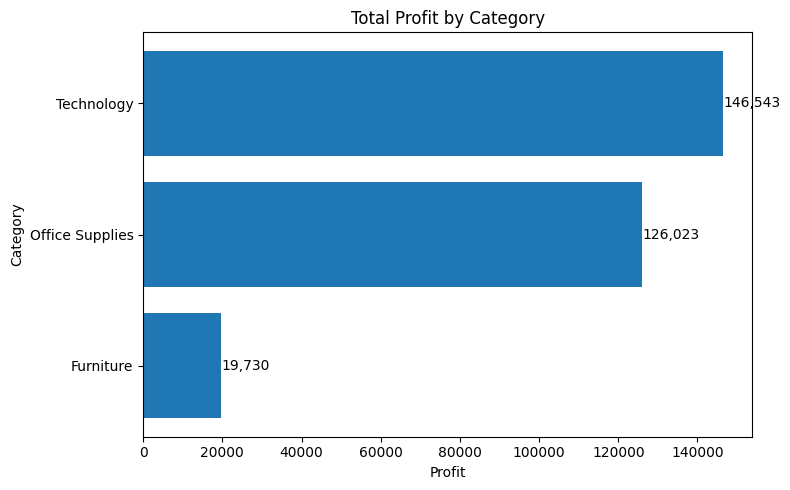

In [20]:
plt.figure(figsize=(8, 5))

bars = plt.barh(
    profit_by_category["category"],
    profit_by_category["profit"]
)

plt.title("Total Profit by Category")
plt.xlabel("Profit")
plt.ylabel("Category")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

In [21]:
profit_by_category["profit_pct"] = (
    profit_by_category["profit"]
    / profit_by_category["profit"].sum()
    * 100
)

profit_by_category

,category,profit,profit_pct
2,Technology,146543.3756,50.135126
1,Office Supplies,126023.4434,43.114888
0,Furniture,19729.9956,6.749987


### Data Summary

Total profit was aggregated by product category to compare each category's contribution to the company's overall profitability.

### Key Observations

- Technology generated the highest total profit.
- Suprisingly, Office Supplies ranked second.
- Furniture generated the least profit.
- Profit distribution is less balanced than sales distribution.

### Business Interpretation

Tchnology was the most profitable category. Furniture, despite of having more sales than Office supplies, generated least profit. In fact, it contributed just 6.7 % of the total profit generation.

### Recommendations

- Prioritize investment in the most profitable category, i.e., Technology.
- Investigate operational or pricing improvements for furniture.
- Avoid evaluating product performance based solely on sales.
- Compare category discounts in the next analysis to determine whether promotional strategies are affecting profitability.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Sales by Sub-Category

### Objective

Analyze total sales across product sub-categories to identify the highest and lowest revenue-generating product groups.

In [22]:
sales_by_subcategory = (
    df.groupby("sub_category", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)

sales_by_subcategory

,sub_category,sales
5,Chairs,335768.2490
13,Phones,331842.6400
14,Storage,224644.5540
16,Tables,208020.1820
3,Binders,207354.8810
11,Machines,189925.0310
0,Accessories,167380.3180
6,Copiers,150745.2900
4,Bookcases,115361.2043
1,Appliances,108213.1850


In [23]:
sales_by_subcategory["sales_pct"] = (
    sales_by_subcategory["sales"]
    / sales_by_subcategory["sales"].sum()
    * 100
)

sales_by_subcategory

,sub_category,sales,sales_pct
5,Chairs,335768.2490,14.432121
13,Phones,331842.6400,14.263389
14,Storage,224644.5540,9.655759
16,Tables,208020.1820,8.941204
3,Binders,207354.8810,8.912608
11,Machines,189925.0310,8.163431
0,Accessories,167380.3180,7.194406
6,Copiers,150745.2900,6.479392
4,Bookcases,115361.2043,4.958500
1,Appliances,108213.1850,4.651261


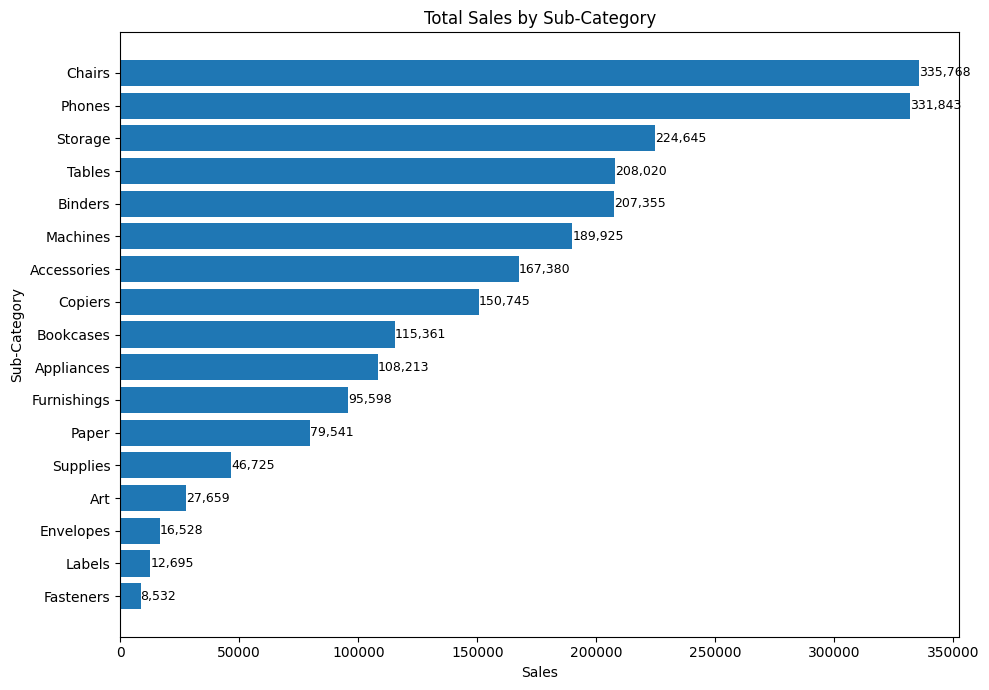

In [24]:
plt.figure(figsize=(10, 7))

bars = plt.barh(
    sales_by_subcategory["sub_category"],
    sales_by_subcategory["sales"]
)

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Data Summary

Total sales were aggregated for each product sub-category to evaluate their contribution to overall revenue and identify the strongest and weakest performing product groups.

### Key Observations

- Chairs generated the highest sales (335,768), closely followed by Phones (331,843), indicating strong customer demand for these product groups.
- Storage ranked third with total sales of 224,645, while Tables and Binders also contributed significantly to overall revenue.
- Fasteners, Labels, and Envelopes recorded the lowest sales, suggesting relatively limited demand compared with other product groups.
- Sales are unevenly distributed across sub-categories, with a small number of product groups contributing a disproportionately large share of total revenue.
- The difference between the highest-selling sub-category (Chairs) and the lowest-selling sub-category (Fasteners) is substantial, highlighting considerable variation in customer purchasing behavior.

### Business Interpretation

The analysis indicates that customer demand is concentrated in a few high-performing product groups, particularly Chairs and Phones. These sub-categories represent important revenue drivers and should receive continued attention in inventory planning and promotional strategies. Conversely, consistently low-selling products such as Fasteners and Labels may require a review of pricing, merchandising, or product assortment to determine whether demand can be improved or inventory should be optimized.

### Recommendations

- Prioritize inventory availability for high-demand sub-categories such as Chairs and Phones to minimize stockouts.
- Continue investing in marketing initiatives for top-performing product groups to sustain revenue growth.
- Review pricing, promotions, and customer demand for low-performing sub-categories to identify opportunities for improvement.
- Evaluate whether low-selling products should be bundled with popular items or have their assortment optimized based on profitability.

-----------------------------------------------------------------------------------------------------------------------

# Profit by Sub-Category

## Business Question

### Which sub-categories contribute the most and least profit, and which ones are causing losses despite generating sales?

In [25]:
profit_by_subcategory = (
    df.groupby("sub_category", as_index=False)["profit"]
      .sum()
      .sort_values(by="profit", ascending=False)
)

profit_by_subcategory

,sub_category,profit
6,Copiers,56093.9365
13,Phones,45050.8265
0,Accessories,41936.6357
12,Paper,34511.5070
3,Binders,31426.1003
5,Chairs,27223.5323
14,Storage,21285.1115
1,Appliances,18329.4844
9,Furnishings,13891.7430
7,Envelopes,6988.0247


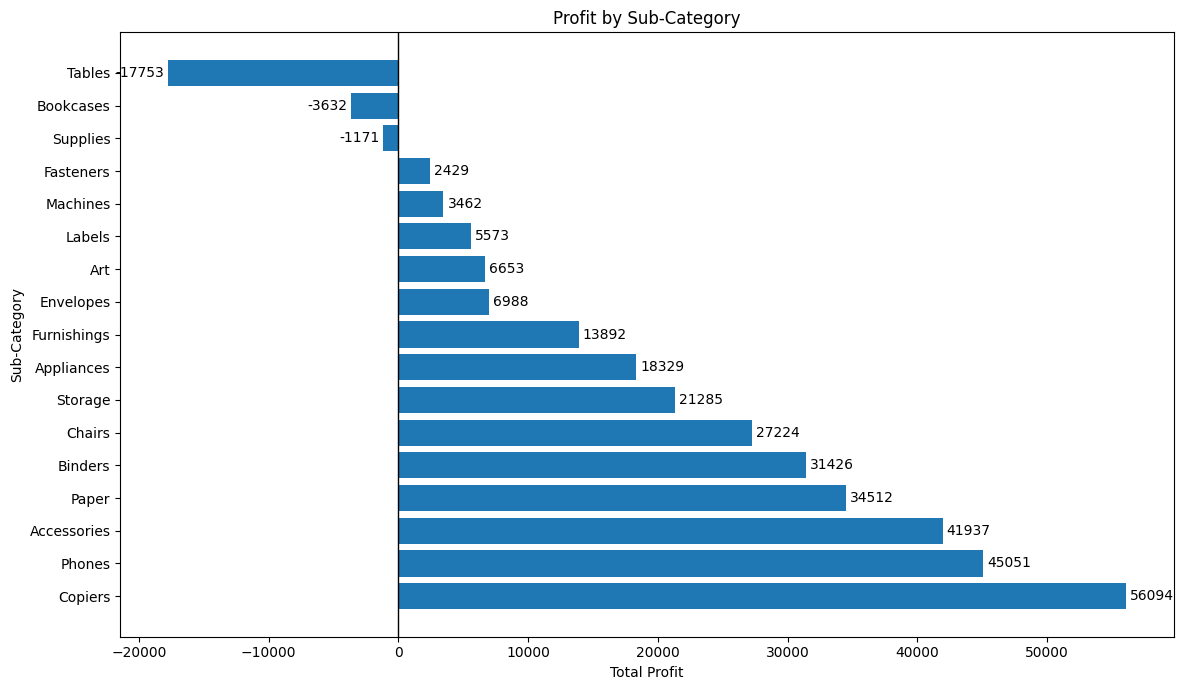

In [26]:
plt.figure(figsize=(12, 7)) # Create a horizontal bar chart to visualize total profit by sub-category

bars = plt.barh(
    profit_by_subcategory["sub_category"],
    profit_by_subcategory["profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.axvline(x=0, color="black", linewidth=1)
plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

plt.tight_layout()
plt.show()

### Data Summary
The chart compares the total profit generated by each product sub-category. While most sub-categories contribute positively to overall profitability, the magnitude of profits varies considerably. Copiers, Phones, and Accessories are the leading profit contributors, whereas Tables, Bookcases, and Supplies generate net losses.

### Key Observations

* Copiers generated the highest total profit among all sub-categories.
* Phones and Accessories are also major contributors to company profit.
* Most sub-categories are profitable, indicating a generally healthy product portfolio.
* Tables recorded the largest overall loss, making it the weakest-performing sub-category in terms of profitability.
* Bookcases and Supplies also generated negative profits, though their losses are substantially smaller than those of Tables.
* The large variation in profitability across sub-categories suggests that sales performance alone does not determine business success.

### Business Interpretation
The analysis indicates that not all product categories contribute equally to business performance. High-profit sub-categories such as Copiers and Phones likely benefit from favorable pricing, healthier margins, or lower operational costs. In contrast, persistent losses in Tables, Bookcases, and Supplies suggest potential issues related to pricing strategies, excessive discounting, procurement costs, or customer demand. These findings highlight the importance of evaluating profitability alongside sales when making inventory and pricing decisions.

### Recommendations

* Continue investing in high-profit sub-categories such as Copiers, Phones, and Accessories through inventory planning and targeted marketing.
* Conduct a detailed review of Tables, Bookcases, and Supplies to identify the primary causes of their negative profitability.
* Evaluate pricing and discount policies for loss-making products to determine whether excessive discounts are eroding margins.
* Review supplier costs and operational expenses associated with low-performing sub-categories to identify cost reduction opportunities.
* Prioritize profitability metrics, in addition to sales volume, when making future product portfolio decisions.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Loss-Making Sub-Categories

## Business Question

### Which sub-categories are generating losses, and how significant are those losses?

In [27]:
loss_making_subcategories = (      #Loss making sub-categories are those with negative profit values. 
    profit_by_subcategory[profit_by_subcategory["profit"] < 0]
    .sort_values(by="profit", ascending=True)
)

loss_making_subcategories

,sub_category,profit
16,Tables,-17753.2061
4,Bookcases,-3632.0736
15,Supplies,-1171.3945


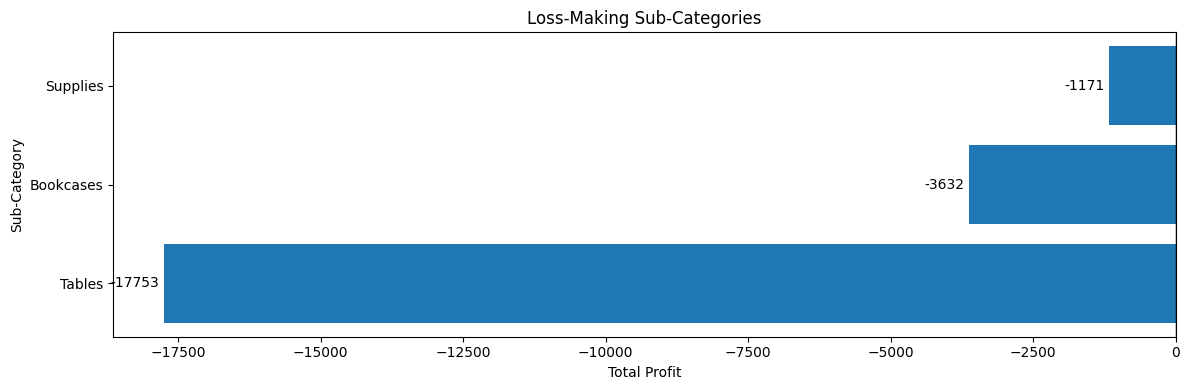

In [28]:
plt.figure(figsize=(12,4)) #Create a horizontal bar chart to visualize loss-making sub-categories

bars = plt.barh(
    loss_making_subcategories["sub_category"],
    loss_making_subcategories["profit"]
)

plt.title("Loss-Making Sub-Categories")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

plt.axvline(x=0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

### Data Summary

This analysis focuses exclusively on sub-categories that generated negative total profits. Out of all product sub-categories, only Tables, Bookcases, and Supplies recorded overall losses. Among them, Tables contributed the largest negative profit by a considerable margin.

### Key Observations
 
* Only three sub-categories generated negative total profits.
* Tables recorded the highest overall loss, substantially exceeding the losses of the other two sub-categories.
* Bookcases also generated a noticeable loss, although significantly smaller than that of Tables.
* Supplies experienced a relatively minor loss compared to the other loss-making sub-categories.
* The concentration of losses within a small number of product lines suggests that overall profitability could improve by addressing these specific underperforming sub-categories.

### Business Interpretation

The findings indicate that losses are not spread evenly across the product portfolio but are concentrated in a few specific sub-categories. This presents an opportunity for targeted corrective action rather than broad changes across all products. In particular, the substantial losses associated with Tables warrant further investigation into factors such as pricing strategies, discount policies, procurement costs, and customer purchasing behavior. Addressing the root causes within these sub-categories could significantly improve overall business profitability.

### Recommendations

* Prioritize a detailed profitability review of the Tables sub-category to identify the primary drivers of its losses.
* Reassess pricing and discount strategies for Tables, Bookcases, and Supplies to ensure profit margins are protected.
* Review supplier contracts, procurement costs, and operational expenses associated with these products to identify cost-saving opportunities.
* Monitor the financial performance of these sub-categories regularly to evaluate the effectiveness of corrective actions.
* Use subsequent analyses, including customer behavior and discount analysis, to determine whether specific customer segments or promotional strategies contribute to these losses.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Product Analysis Summary

## Objective

### Summarize the key findings from all product-related analyses and provide strategic business recommendations before transitioning to customer-focused analysis.

The product analysis reveals significant variation in performance across categories and sub-categories. While most product lines contribute positively to the company's profitability, a small number of sub-categories consistently underperform and reduce overall financial performance.

Technology products, particularly Copiers, Phones, and Accessories, emerged as the strongest profit contributors, indicating high demand and healthy profit margins. In contrast, sub-categories such as Tables, Bookcases, and Supplies generated net losses despite contributing to overall sales. This highlights that strong sales do not necessarily translate into strong profitability.

The analysis also demonstrates that profitability is concentrated within a limited number of product lines, suggesting that strategic decisions should prioritize profit contribution rather than sales volume alone.

## Key Business Insights

* Technology products are the primary drivers of overall profitability.
* Profitability varies considerably across product sub-categories.
* High sales do not always result in high profits.
* Only a small number of sub-categories account for the company's product-related losses.
* Targeted improvements to underperforming products could significantly improve overall business performance without major changes to the broader product portfolio.

## Strategic Recommendations

* Continue investing in high-performing product lines such as Copiers, Phones, and Accessories.
* Investigate the causes of losses in Tables, Bookcases, and Supplies, with particular attention to pricing, discounts, and procurement costs.
* Prioritize profitability alongside sales when evaluating product performance.
* Regularly monitor product-level profitability to identify emerging issues before they significantly impact business results.
* Use the upcoming customer and discount analyses to determine whether purchasing behavior or promotional strategies are contributing to the observed losses.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Customer Analysis

## Top 10 Customers by Sales

### Objective
Analyze customer-wise sales to identify the highest revenue-generating customers and understand how sales are distributed among the top customers. The analysis aims to help the business recognize its most valuable revenue contributors and support customer relationship and retention strategies.

In [33]:
top_customers = (
    df.groupby("customer_name", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
      .head(10)
      .reset_index(drop=True)
)

top_customers

,customer_name,sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


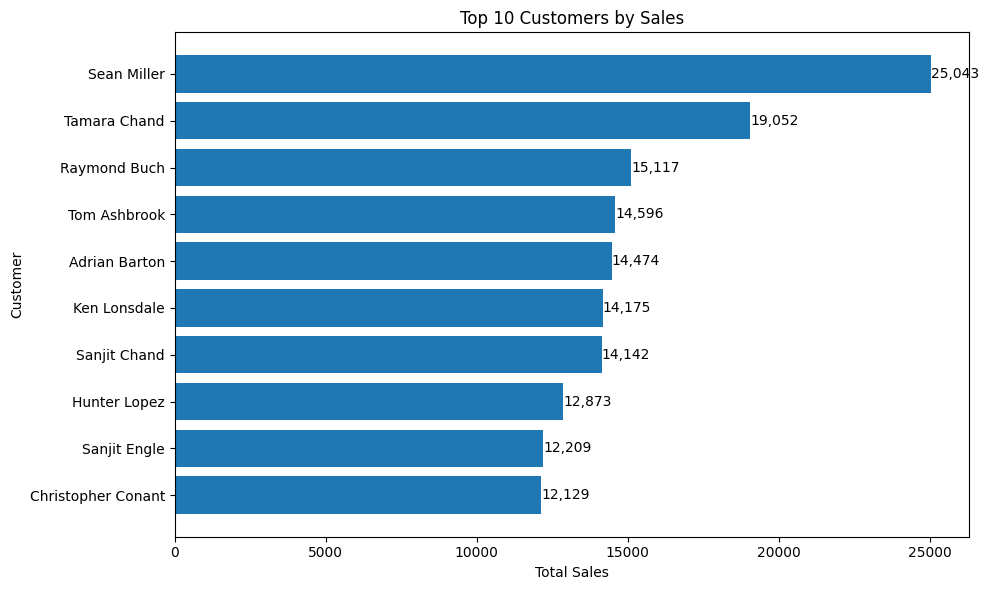

In [30]:
plt.figure(figsize=(10, 6)) #Create a horizontal bar chart to visualize the top 10 customers by sales

plt.barh(
    top_customers["customer_name"],
    top_customers["sales"]
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

for i, value in enumerate(top_customers["sales"]):
    plt.text(value, i, f"{value:,.0f}", va="center")

plt.tight_layout()
plt.show()

### Data Summary
The dataset was aggregated by customer_name, and the total sales generated by each customer were calculated. The top 10 customers were then selected based on their cumulative sales and visualized using a horizontal bar chart for easy comparison.

### Key Observations

* Sean Miller generated the highest total sales among all customers, contributing over 25,000 in total revenue.
* Tamara Chand ranked second with approximately 19,000 in sales, showing a noticeable gap from the top customer.
* The remaining top customers generated between approximately 12,000 and 15,000 in sales, indicating relatively similar revenue contributions within this group.
* The distribution suggests that while one customer clearly leads in revenue generation, several other customers also contribute significantly to overall sales.
* This analysis measures sales only and does not account for profitability or discounts. Therefore, higher sales do not necessarily imply greater business value.

### Business Interpretation
A small group of customers contributes a disproportionately high share of total revenue, making them strategically important to the business. Retaining these customers through strong relationships, personalized engagement, and high service quality can have a significant impact on maintaining revenue. However, revenue alone should not drive customer prioritization. Further analysis of customer profitability is required to determine whether these high-sales customers also contribute positively to overall profit.

### Recommendations

* Develop retention programs for the highest revenue-generating customers to encourage repeat purchases.
* Investigate purchasing patterns of top customers to identify opportunities for cross-selling and upselling.
* Compare customer sales with customer profit in the next analysis to identify customers who generate high revenue but low profitability.
* Use these insights to support customer segmentation and prioritize business resources toward customers who contribute the greatest overall value.

-------------------------------------------------------------------------------------------------------------------------------------------------------

## Top Customers by Profit

### Objective
Identify the customers contributing the highest profit to the business and compare profitability across the top-performing customers.

In [32]:
top_profit_customers = (       #Top profit customers are those with the highest total profit values.
    df.groupby("customer_name", as_index=False)["profit"]
      .sum()
      .sort_values("profit", ascending=False)
      .head(10)
      .reset_index(drop=True)
)

top_profit_customers

,customer_name,profit
0,Tamara Chand,8981.3239
1,Raymond Buch,6976.0959
2,Sanjit Chand,5757.4119
3,Hunter Lopez,5622.4292
4,Adrian Barton,5444.8055
5,Tom Ashbrook,4703.7883
6,Christopher Martinez,3899.8904
7,Keith Dawkins,3038.6254
8,Andy Reiter,2884.6208
9,Daniel Raglin,2869.0760


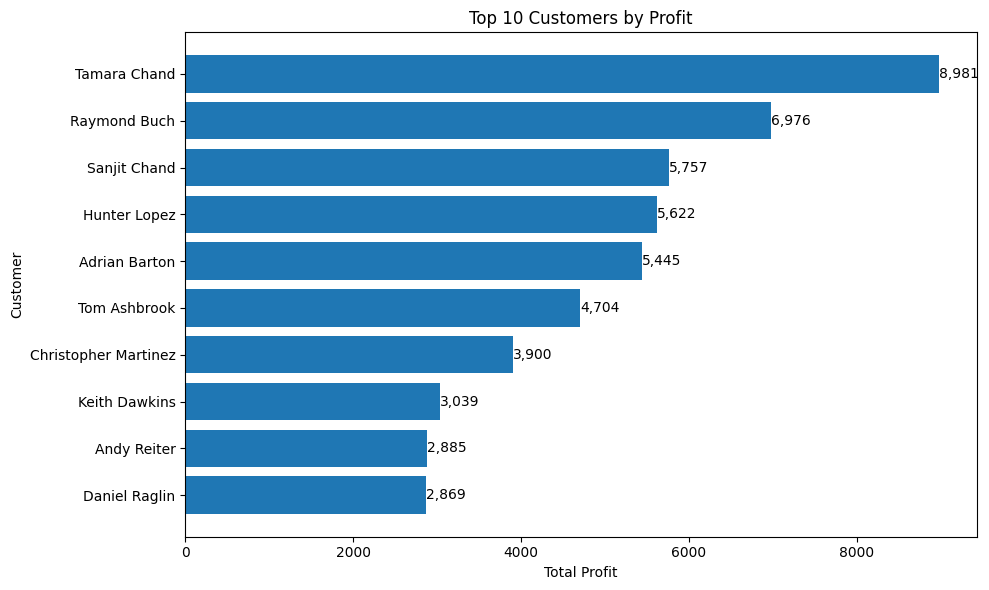

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_profit_customers["customer_name"],
    top_profit_customers["profit"]
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

for i, value in enumerate(top_profit_customers["profit"]):
    plt.text(value, i, f"{value:,.0f}", va="center")

plt.tight_layout()
plt.show()

### Data Summary

The dataset was aggregated by customer_name, and the total profit generated by each customer was calculated. The customers were ranked based on cumulative profit, and the top 10 profit-generating customers were visualized using a horizontal bar chart.

### Key Observations

* Tamara Chand generated the highest cumulative profit, contributing approximately 8,981 in total profit.
* Raymond Buch ranked second with nearly 6,976 in profit.
* Sean Miller, despite being the highest revenue-generating customer, did not appear among the top 10 most profitable customers.
* Several customers, including Christopher Martinez, Keith Dawkins, Andy Reiter, and Daniel Raglin, entered the top profit ranking despite not being among the highest sales contributors.
* The variation between the sales and profit rankings suggests that customer profitability depends on more than just purchase volume. Factors such as product mix and discount levels likely influence profit generation.

### Business Interpretation

Revenue alone is not a sufficient measure of customer value. Customers generating high sales may also receive substantial discounts or primarily purchase lower-margin products, reducing overall profitability. Conversely, some customers generate relatively lower sales while consistently purchasing higher-margin products, making them more valuable from a profit perspective. Businesses should therefore evaluate customers using both revenue and profit metrics when designing sales and retention strategies.

### Recommendations

* Prioritize retention efforts for customers who consistently generate high profit rather than focusing solely on high sales.
* Investigate why some high-sales customers do not translate into high profitability by analyzing discounts, product categories, and purchasing behavior.
* Encourage sales teams to promote higher-margin products to customers with strong purchasing potential.
* Incorporate profitability metrics into customer segmentation to better allocate marketing resources and improve overall business performance.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Customer Revenue Contribution (Pareto Analysis)

### Business Question

Does a small percentage of customers contribute a large share of total sales?

### Objective

Analyze the cumulative sales contribution of customers to determine whether revenue is concentrated among a small group of customers and identify opportunities for customer retention strategies.

In [35]:
customer_sales = (
    df.groupby("customer_name", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
      .reset_index(drop=True)
)

customer_sales["cumulative_sales"] = customer_sales["sales"].cumsum()

total_sales = customer_sales["sales"].sum()

customer_sales["cumulative_sales_pct"] = (
    customer_sales["cumulative_sales"] / total_sales * 100
)

customer_sales["customer_pct"] = (
    (customer_sales.index + 1) / len(customer_sales) * 100
)

customer_sales.head()

,customer_name,sales,cumulative_sales,cumulative_sales_pct,customer_pct
0,Sean Miller,25043.050,25043.050,1.076410,0.125
1,Tamara Chand,19052.218,44095.268,1.895320,0.250
2,Raymond Buch,15117.339,59212.607,2.545099,0.375
3,Tom Ashbrook,14595.620,73808.227,3.172454,0.500
4,Adrian Barton,14473.571,88281.798,3.794562,0.625


In [38]:
customers_for_80 = customer_sales[
    customer_sales["cumulative_sales_pct"] >= 80
].iloc[0]

customer_threshold = customers_for_80["customer_pct"]
sales_threshold = customers_for_80["cumulative_sales_pct"]

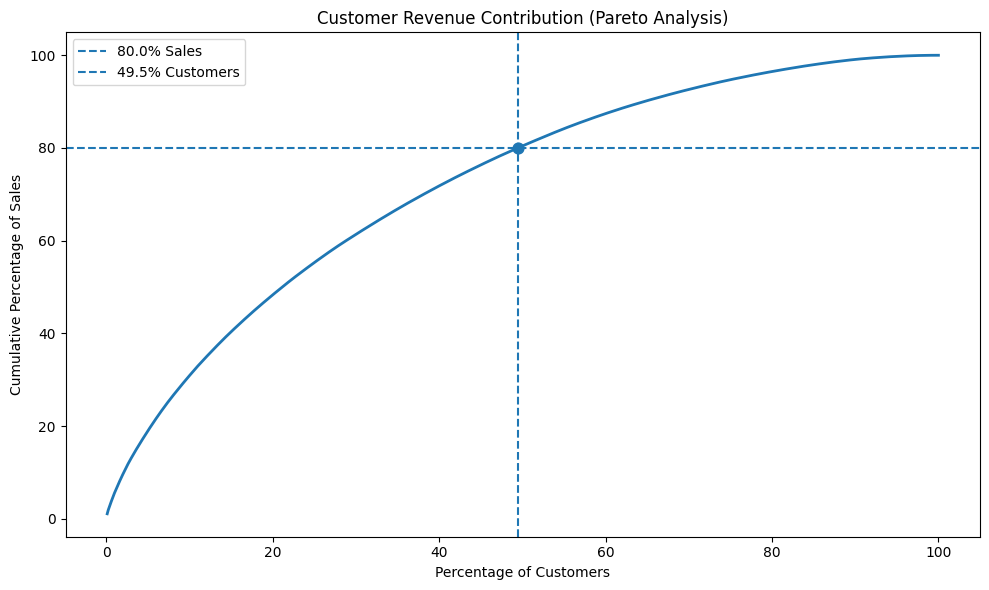

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    customer_sales["customer_pct"],
    customer_sales["cumulative_sales_pct"],
    linewidth=2
)

plt.axhline(
    sales_threshold,
    linestyle="--",
    label=f"{sales_threshold:.1f}% Sales"
)

plt.axvline(
    customer_threshold,
    linestyle="--",
    label=f"{customer_threshold:.1f}% Customers"
)

plt.scatter(
    customer_threshold,
    sales_threshold,
    s=60
)

plt.title("Customer Revenue Contribution (Pareto Analysis)")
plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Percentage of Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [40]:
customers_for_80 = customer_sales[
    customer_sales["cumulative_sales_pct"] >= 80
].iloc[0]

customers_for_80

customer_name           Craig Carreira
sales                        2269.7015
cumulative_sales          1862075.1074
cumulative_sales_pct         80.036433
customer_pct                      49.5
Name: 395, dtype: object

### Objective

Analyze how total sales are distributed across customers and determine whether revenue is concentrated among a small percentage of customers.   

### Data Summary

Customers were ranked in descending order of total sales. Cumulative sales and cumulative sales percentages were then calculated to evaluate how revenue accumulates across the customer base. A Pareto chart was used to visualize the relationship between the percentage of customers and the percentage of total sales they contribute.


### Key Observations

* Approximately 49.3% of customers account for 80% of total sales.
* The cumulative sales curve rises steadily rather than sharply, indicating that revenue is distributed across a relatively broad customer base.
* The dataset does not exhibit the classic 80/20 Pareto distribution, where approximately 20% of customers contribute 80% of sales.
* A large proportion of customers contribute meaningfully to overall revenue, suggesting that the business is not overly dependent on a small number of customers.

### Business Interpretation

The company's revenue is moderately distributed across its customers rather than being concentrated among a small elite group. This diversified customer base reduces dependence on a handful of customers and lowers the business risk associated with losing any single customer. However, it also means that improving customer retention and engagement across a broader segment of customers may have a greater impact on overall revenue than focusing exclusively on a few top accounts.

### Recommendations

* Continue investing in customer retention initiatives across a broad customer base rather than targeting only the highest-spending customers.
* Develop customer segmentation strategies to identify groups with strong growth potential instead of focusing solely on the current top customers.
* Design loyalty and personalized marketing programs that encourage mid-tier customers to increase their purchasing frequency and order value.
* Combine this analysis with customer profitability to identify customers who contribute both significant revenue and strong profit.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Customer Purchase Frequency

### Business Question

Which customers place orders most frequently?

# Objective

Analyze customer purchase frequency to identify the most active customers and understand their contribution to customer engagement and potential loyalty.

In [41]:
customer_frequency = (
    df.groupby("customer_name")["order_id"]
      .nunique()
      .reset_index(name="total_orders")
      .sort_values("total_orders", ascending=False)
      .reset_index(drop=True)
)

customer_frequency.head(10)

,customer_name,total_orders
0,Emily Phan,17
1,Bart Pistole,14
2,Suzanne McNair,14
3,Eugene Hildebrand,14
4,Noel Staavos,13
5,Ben Ferrer,13
6,William Brown,13
7,Joel Eaton,13
8,Chloris Kastensmidt,13
9,Patrick Gardner,13


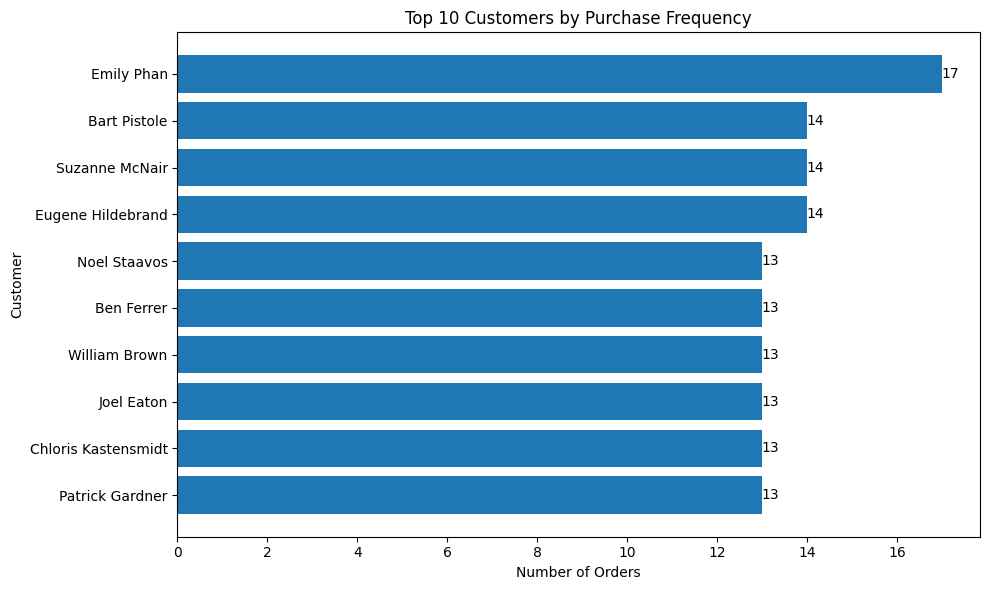

In [42]:
plt.figure(figsize=(10, 6))

plt.barh(
    customer_frequency.head(10)["customer_name"],
    customer_frequency.head(10)["total_orders"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")

for i, value in enumerate(customer_frequency.head(10)["total_orders"]):
    plt.text(value, i, str(value), va="center")

plt.tight_layout()
plt.show()

### Objective

Analyze customer purchase frequency to identify the most active customers and understand whether frequent purchasing behavior aligns with high sales or profitability.

### Data Summary

The number of unique orders placed by each customer was calculated using the order_id field. Customers were then ranked by total order count, and the top 10 customers with the highest purchase frequency were visualized using a horizontal bar chart.

### Key Observations

* Emily Phan placed the highest number of unique orders, with 17 purchases.
* Three customers each placed 14 orders, while several others recorded 13 orders, indicating relatively small differences in purchase frequency among the most active customers.
* The customers with the highest purchase frequency are different from those identified in the top sales and top profit analyses.
* This suggests that customers who purchase more frequently do not necessarily generate the highest revenue or profit, highlighting differences in purchasing behavior and average order value.

### Business Interpretation

Purchase frequency represents customer engagement rather than customer value. Customers who place frequent orders may make smaller purchases, whereas customers who purchase less often may contribute significantly higher revenue or profit through larger transactions. Therefore, evaluating customers solely based on purchase frequency can lead to misleading business decisions. A comprehensive customer assessment should consider purchase frequency alongside sales and profitability.

### Recommendations

* Reward highly engaged customers through loyalty programs to encourage continued repeat purchases.
* Identify opportunities to increase the average order value of frequent purchasers using cross-selling and upselling strategies.
* Analyze customers with high sales but low purchase frequency to understand the characteristics of high-value transactions.
* Combine purchase frequency, sales, and profit metrics to create customer segments that support more effective marketing and retention strategies.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Customer Analysis — Overall Insights

### 1. Top Customers by Sales

Question: Who generates the highest revenue?

Insights:

* Sean Miller generated the highest total sales (~25k).
* Tamara Chand ranked second.
* Several customers generated between ~12k–15k in sales.
* High sales indicate strong revenue contribution but do not necessarily imply high business value.

### 2. Top Customers by Profit

Question: Who generates the highest profit?

Insights:

* Tamara Chand became the most profitable customer (~9k profit).
* Sean Miller disappeared from the top 10 profit list.
* New customers entered the ranking despite not having the highest sales.
* Revenue ≠ Profit.
* Product mix, discounts, and margins significantly influence profitability.

### 3. Customer Revenue Contribution (Pareto Analysis)

Question: Is revenue concentrated among a small group of customers?

Insights:

* About 49.3% of customers generate 80% of total sales.
* The dataset does not follow the classic 80/20 Pareto Principle.
* Revenue is distributed across a relatively broad customer base.
* The business is not overly dependent on a handful of customers, reducing concentration risk.

### 4. Customer Purchase Frequency

Question: Who buys most frequently?

Insights:

* Emily Phan placed the highest number of unique orders (17).
* Frequent purchasers are different from the top sales and top profit customers.
* Purchase frequency measures engagement, not necessarily customer value.
* Some customers place many small orders, while others place fewer but much larger or more profitable orders.

## Business Story

Not all high-revenue customers are highly profitable -------> Revenue is spread across a broad customer base rather than concentrated among a few customers -----------> The most frequent purchasers are not the highest revenue or profit contributors. ------------------>  Customer value cannot be measured using a single metric. Sales, profit, revenue contribution, and purchase frequency together provide a more complete understanding of customer behavior.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Discount Analysis

## Discount Distribution

### Business question:

How are discounts distributed across all orders?

### Objective

Understand how discounts are distributed across customer orders. This analysis helps identify the company's pricing strategy, determine whether most products are sold at full price or with discounts, and assess how frequently high discount levels are used.

In [43]:
discount_summary = (
    df["discount"]
    .value_counts()
    .sort_index()
    .reset_index()
)

discount_summary.columns = ["discount", "order_count"]

discount_summary

,discount,order_count
0,0.00,4925
1,0.10,96
2,0.15,52
3,0.20,3706
4,0.30,230
5,0.32,27
6,0.40,207
7,0.45,11
8,0.50,66
9,0.60,149


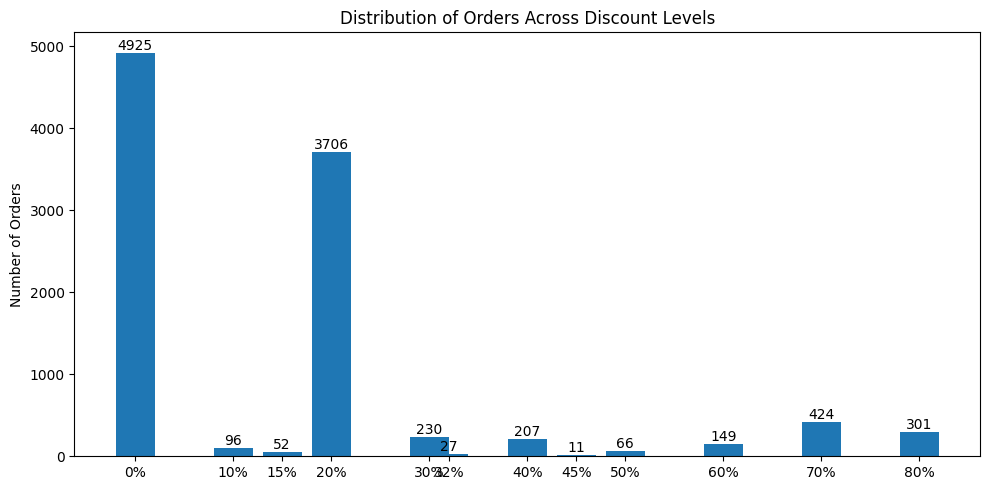

In [46]:
plt.figure(figsize=(10,5)) #Create a bar chart to visualize the distribution of orders across different discount levels

bars = plt.bar(
    discount_summary["discount"],
    discount_summary["order_count"],
    width=0.04
)

plt.title("Distribution of Orders Across Discount Levels")
plt.xticks(discount_summary["discount"],
           [f"{d:.0%}" for d in discount_summary["discount"]])
plt.ylabel("Number of Orders")

plt.bar_label(bars)

plt.tight_layout()
plt.show()

### Data Summary

The dataset contains orders distributed across 12 discrete discount levels, ranging from 0% to 80%. Two discount levels dominate the dataset: 0% (4,925 orders) and 20% (3,706 orders), while all remaining discount levels occur far less frequently. This indicates that the company primarily relies on either full-price sales or a standard 20% discount strategy.

### Key Observations

* Nearly half of all orders are sold without any discount (0%), making it the most common pricing strategy.
* A 20% discount is the second most frequently applied pricing level, suggesting it is a standard promotional discount.
* Discount levels between 10% and 60% are used relatively infrequently compared to 0% and 20%.
* Higher discount levels such as 70% and 80% appear less often but are still applied to several hundred orders, indicating occasional aggressive discounting.

### Business Interpretation

The pricing strategy appears to rely heavily on two approaches: selling products at full price and offering a standard 20% discount. Larger discounts are used selectively, suggesting they may be reserved for inventory clearance, promotional campaigns, or highly competitive products. While this distribution explains how discounts are applied, it does not reveal whether these discounts improve or reduce profitability, which motivates the next analysis.

### Recommendations

* Continue evaluating the effectiveness of the standard 20% discount, as it represents a substantial portion of all transactions.
* Review the business justification for very high discounts (70%–80%) to ensure they generate strategic value rather than unnecessary profit erosion.
* Investigate whether orders receiving higher discounts contribute positively to overall profitability before expanding discount-based promotions.

While this analysis explains how frequently different discount levels are used, it does not indicate whether these pricing decisions improve or reduce profitability. The next analysis examines the relationship between discounts and profit to determine whether increasing discounts are financially sustainable.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Discount vs Profit

### Objective

Analyze the relationship between discounts and profitability at the order level. This analysis aims to determine whether increasing discounts are associated with lower profits and identify any overall trend between pricing decisions and financial performance.

In [47]:
correlation = df["discount"].corr(df["profit"])

print(f"Correlation between Discount and Profit: {correlation:.3f}")

Correlation between Discount and Profit: -0.219


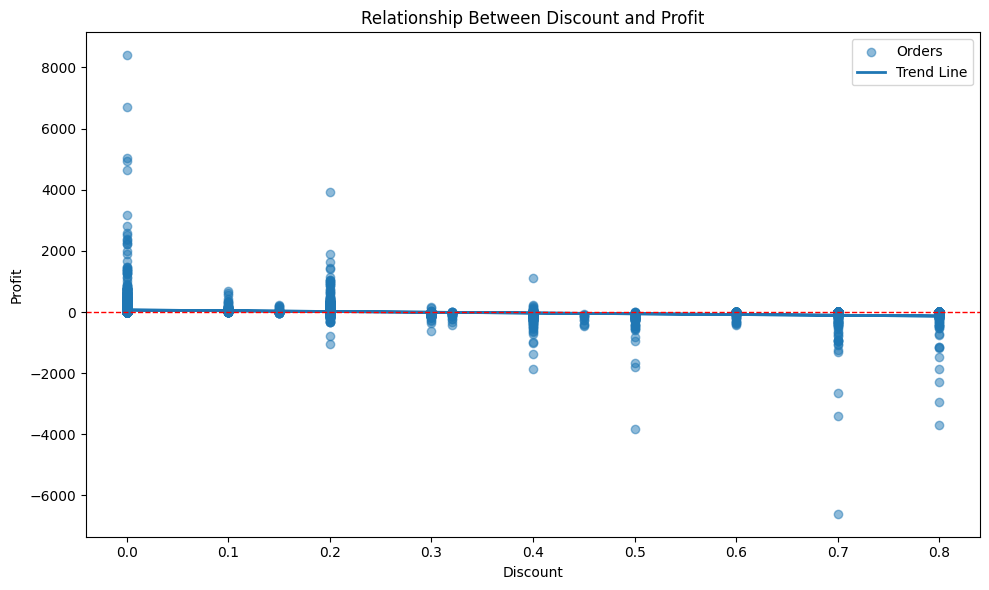

In [50]:
z = np.polyfit(df["discount"], df["profit"], 1)
p = np.poly1d(z)

plt.figure(figsize=(10,6))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.5,
    label="Orders"
)

plt.plot(
    df["discount"],
    p(df["discount"]),
    linewidth=2,
    label="Trend Line"
)

plt.axhline(0, color="red", linestyle="--", linewidth=1)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.legend()

plt.tight_layout()
plt.show()

### Data Summary

The correlation coefficient between discount and profit is **-0.219**, indicating a weak negative relationship. While higher discounts tend to be associated with lower profits, the relationship is not strong enough to conclude that discounts alone determine profitability. The scatter plot further shows considerable variation in profit at each discount level, suggesting that other factors such as product category, sales volume, and cost structure also influence financial performance.

### Key Observations

- The correlation coefficient of **-0.219** indicates a weak negative relationship between discount and profit.
- As discount levels increase, the overall trend line slopes downward, suggesting that profitability generally declines with higher discounts.
- Orders with little or no discount exhibit the widest range of profits, including many of the highest-profit transactions.
- High discount levels (particularly 70% and 80%) contain a noticeably larger concentration of loss-making orders.
- Considerable variation exists within every discount level, indicating that discounts are only one of several factors affecting profitability.

### Business Interpretation

The analysis suggests that increasing discounts generally reduce profitability, although the impact is moderate rather than absolute. The weak negative correlation indicates that discounting alone does not determine profit, but excessive discounts increase the likelihood of financial losses. Other business factors, including product mix, pricing strategy, and customer purchasing behavior, also play significant roles in determining order profitability.

### Recommendations

- Review high-discount pricing strategies to ensure they generate sufficient business value.
- Avoid applying large discounts as a default pricing strategy without evaluating their impact on margins.
- Incorporate additional business factors, such as product category and customer segment, when designing discount policies.
- Perform a deeper analysis of average profit across discount levels to identify specific discount thresholds where profitability begins to decline.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Average Profit by Discount Level

### Business question
At which discount levels does the company start losing money on average?

### Objective

Evaluate the average profit generated at each discount level to identify how discounting affects profitability. This analysis aims to determine whether certain discount levels consistently reduce profit and identify thresholds where discounts begin to negatively impact financial performance.

In [51]:
avg_profit_discount = (
    df.groupby("discount", as_index=False)["profit"]
      .mean()
      .sort_values("discount")
)

avg_profit_discount.rename(columns={"profit": "average_profit"}, inplace=True)

avg_profit_discount

,discount,average_profit
0,0.00,66.338799
1,0.10,94.791354
2,0.15,27.288298
3,0.20,24.576350
4,0.30,-45.710633
5,0.32,-88.560656
6,0.40,-111.528378
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-41.371458


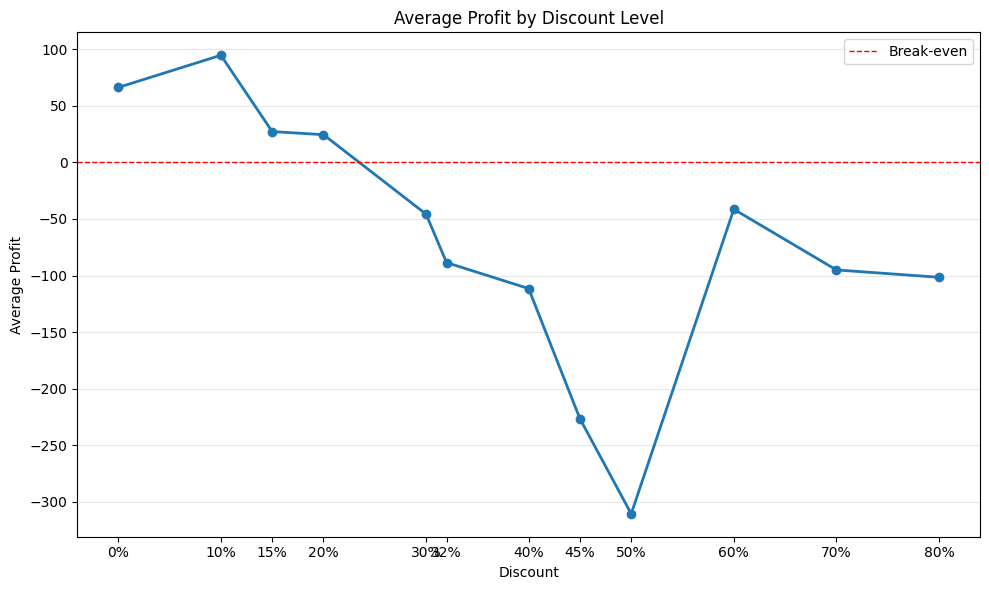

In [52]:
plt.figure(figsize=(10,6))

plt.plot(
    avg_profit_discount["discount"],
    avg_profit_discount["average_profit"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Break-even"
)

plt.xticks(
    avg_profit_discount["discount"],
    [f"{d:.0%}" for d in avg_profit_discount["discount"]]
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

### Data Summary

The average profit was calculated for each discount level to evaluate how profitability changes as larger discounts are offered. The results show a clear shift from positive average profits at lower discount levels to negative average profits at higher discount levels, indicating that aggressive discounting substantially reduces profitability.

### Key Observations

- Orders with discounts between **0% and 20%** generate positive average profits, with the **10% discount level achieving the highest average profit**.
- Profitability declines sharply once discounts exceed **20%**, with the average profit becoming negative from the **30% discount level** onward.
- The **50% discount** produces the largest average loss per order, making it the least profitable discount level in the dataset.
- Although the **60% discount** performs better than the 50% discount, it still results in an average loss, indicating that higher discounts generally remain unprofitable.
- Average profit remains below the break-even point for discount levels of **30% and above**, suggesting that large discounts consistently erode margins.

### Business Interpretation

The results indicate that the company's pricing strategy remains financially sustainable when discounts are limited to 20% or less. Beyond this point, average profitability deteriorates rapidly, with orders receiving discounts of 30% or more generating losses on average. This suggests that while discounts may stimulate sales, excessive discounting significantly reduces profit margins and may outweigh any increase in revenue.

### Recommendations

- Limit routine promotional discounts to **20% or below**, where average profitability remains positive.
- Review the business rationale behind discounts of **30% and above**, as these levels consistently generate losses on average.
- Reassess the use of **50% discounts**, which produce the highest average loss per order and may not be financially sustainable.
- Before approving large discounts, evaluate additional factors such as inventory clearance, customer acquisition, or strategic marketing objectives to ensure that reduced margins are justified.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Loss Rate by Discount Level

### Business Question
At each discount level, what percentage of orders result in a financial loss?

### Objective

Measure the percentage of loss-making orders at each discount level to evaluate the financial risk associated with different discount policies. This analysis helps identify discount thresholds where the likelihood of incurring losses increases significantly.

In [60]:
loss_rate = (
    df.assign(loss_order=df["profit"] < 0)
      .groupby("discount", as_index=False)
      .agg(
          total_orders=("loss_order", "count"),
          loss_orders=("loss_order", "sum")
      )
)


loss_rate["loss_rate"] = (
    loss_rate["loss_orders"] / loss_rate["total_orders"] * 100
)

loss_rate["loss_rate"] = loss_rate["loss_rate"].round(1)

loss_rate

,discount,total_orders,loss_orders,loss_rate
0,0.00,4925,0,0.0
1,0.10,96,4,4.2
2,0.15,52,17,32.7
3,0.20,3706,510,13.8
4,0.30,230,211,91.7
5,0.32,27,27,100.0
6,0.40,207,181,87.4
7,0.45,11,11,100.0
8,0.50,66,66,100.0
9,0.60,149,149,100.0


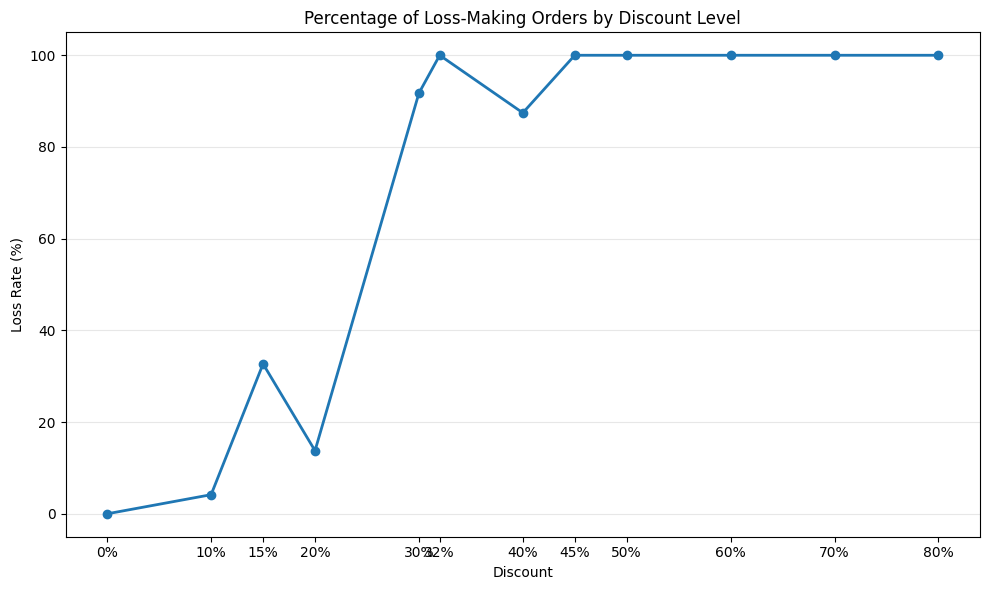

In [55]:
plt.figure(figsize=(10,6))

plt.plot(
    loss_rate["discount"],
    loss_rate["loss_rate"],
    marker="o",
    linewidth=2
)

plt.xticks(
    loss_rate["discount"],
    [f"{d:.0%}" for d in loss_rate["discount"]]
)

plt.ylabel("Loss Rate (%)")
plt.xlabel("Discount")
plt.title("Percentage of Loss-Making Orders by Discount Level")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Data Summary
The percentage of loss-making orders was calculated for each discount level to evaluate the financial risk associated with different discount policies. The results show that the likelihood of generating losses increases substantially as discount levels rise, with several high-discount levels resulting in loss-making orders almost every time.

### Key Observations

- Orders sold without discounts (0%) did not generate any losses, indicating that full-price sales are consistently profitable.
- Discount levels up to **20%** maintain relatively low loss rates, although the proportion of unprofitable orders gradually increases.
- Beginning at a **30% discount**, nearly all orders become loss-making, with the loss rate exceeding **90%**.
- Discount levels of **45% and above** produce a **100% loss rate**, meaning every order at these discount levels results in a financial loss.
- The analysis demonstrates a strong positive relationship between discount size and the probability of incurring losses.

### Business Interpretation

The company's current high-discount pricing strategy exposes it to significant financial risk. While modest discounts can still maintain acceptable profitability, aggressive discounting dramatically increases the likelihood of selling products below profitable margins. The fact that every order with discounts of 45% or higher results in a loss suggests that these discount levels should only be used under exceptional business circumstances, such as inventory liquidation or strategic customer acquisition campaigns.

### Recommendations
- Restrict routine discounts to levels that maintain acceptable profitability, preferably **20% or below**.
- Require additional business justification before approving discounts of **30% or more**.
- Avoid discounts of **45% and above** unless the objective is inventory clearance or another clearly defined strategic initiative.
- Establish profitability monitoring for promotional campaigns to ensure discount policies do not consistently generate financial losses.

## Discount Analysis Summary

The discount analysis reveals a clear trade-off between promotional pricing and profitability. Most orders are sold either at full price or with a standard 20% discount, indicating that these are the company's primary pricing strategies. Although higher discounts are applied less frequently, their financial impact is significant.

Order-level analysis shows a negative relationship between discounts and profit, while aggregated results demonstrate that average profitability becomes negative once discounts exceed 20%. Furthermore, the probability of incurring losses increases sharply with larger discounts, with discounts of 45% and above resulting in loss-making orders in every observed case.

Overall, the findings suggest that moderate discounts can support sales while maintaining profitability, whereas aggressive discounting consistently erodes margins. Future pricing strategies should balance revenue growth with profit protection by limiting high-discount promotions to situations where clear strategic benefits justify the reduced margins.

While discounting influences profitability through pricing decisions, operational efficiency also plays an important role in customer satisfaction and business performance. The next section examines shipping performance to understand how delivery times vary across orders and whether shipping operations present opportunities for improvement.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Shipping Analysis

## Shipping Days Distribution

### Business Objective

1. How long do orders typically take to ship?
2. Which shipping mode is used the most?
3. Which shipping mode is the fastest?
4. Does faster shipping lead to higher sales or profit?
5. Are there operational inefficiencies in shipping?

In [82]:
# Summary statistics for shipping time
df["shipping_days"].describe()





count    10194.000000
mean         3.961350
std          1.742829
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
Name: shipping_days, dtype: float64

In [83]:
df["shipping_days"].value_counts().sort_index()

shipping_days
0      523
1      369
2     1361
3     1025
4     2838
5     2243
6     1204
7      629
11       2
Name: count, dtype: int64

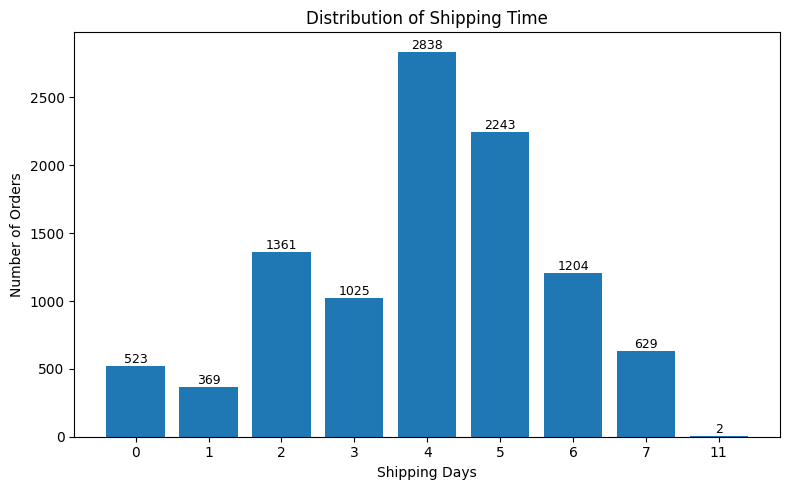

In [62]:
import matplotlib.pyplot as plt #plotting the distribution of shipping time using a bar chart

shipping_counts = (
    df["shipping_days"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    shipping_counts.index.astype(str),
    shipping_counts.values
)

plt.title("Distribution of Shipping Time")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Shipping Mode Usage

### Business question
Which shipping mode is used most frequently?

In [63]:
shipping_mode = (
    df.groupby("ship_mode")
      .size()
      .sort_values(ascending=False)
)

shipping_mode

ship_mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
dtype: int64

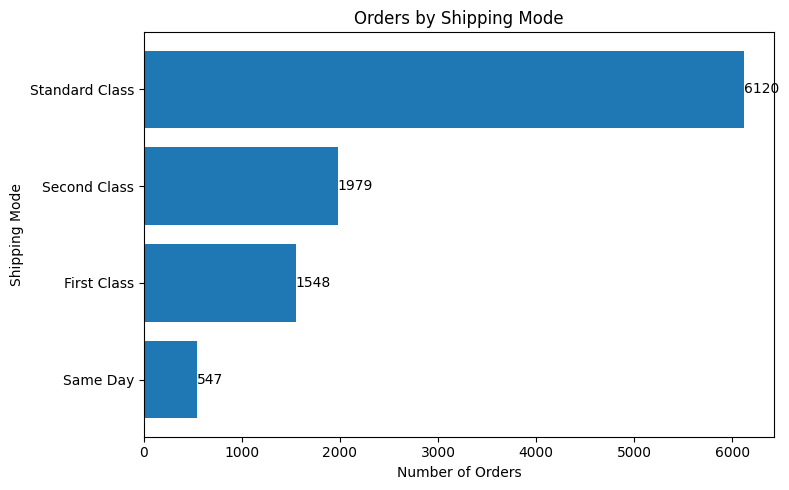

In [64]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    shipping_mode.index,
    shipping_mode.values
)

plt.title("Orders by Shipping Mode")
plt.xlabel("Number of Orders")
plt.ylabel("Shipping Mode")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

## Average Shipping Time by Shipping Mode

### Business question
Which shipping mode delivers orders the fastest on average?

In [65]:
avg_shipping = (
    df.groupby("ship_mode")["shipping_days"]
      .mean()
      .sort_values()
)

avg_shipping

ship_mode
Same Day          0.043876
First Class       2.182171
Second Class      3.237999
Standard Class    4.995425
Name: shipping_days, dtype: float64

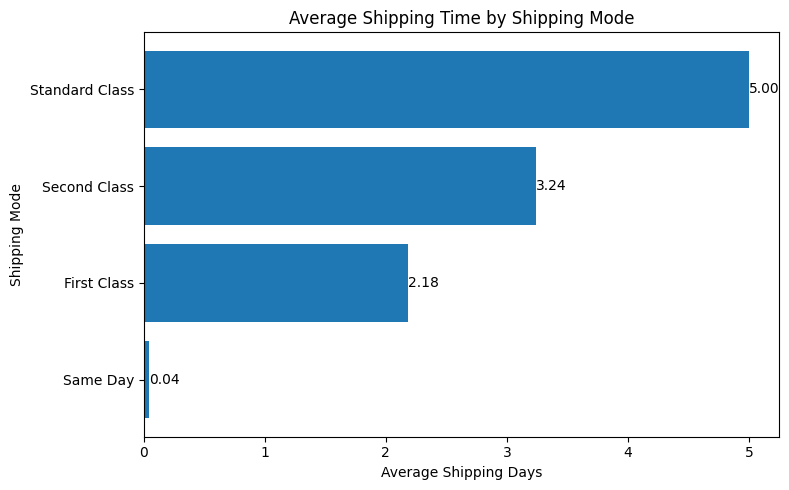

In [66]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    avg_shipping.index,
    avg_shipping.values
)

plt.title("Average Shipping Time by Shipping Mode")
plt.xlabel("Average Shipping Days")
plt.ylabel("Shipping Mode")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## Sales by Shipping Mode
### Business question

Which shipping mode generates the highest sales?

In [71]:
sales_shipping = (
    df.groupby("ship_mode")["sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_shipping

ship_mode
Standard Class    1.378841e+06
Second Class      4.666711e+05
First Class       3.517507e+05
Same Day          1.292720e+05
Name: sales, dtype: float64

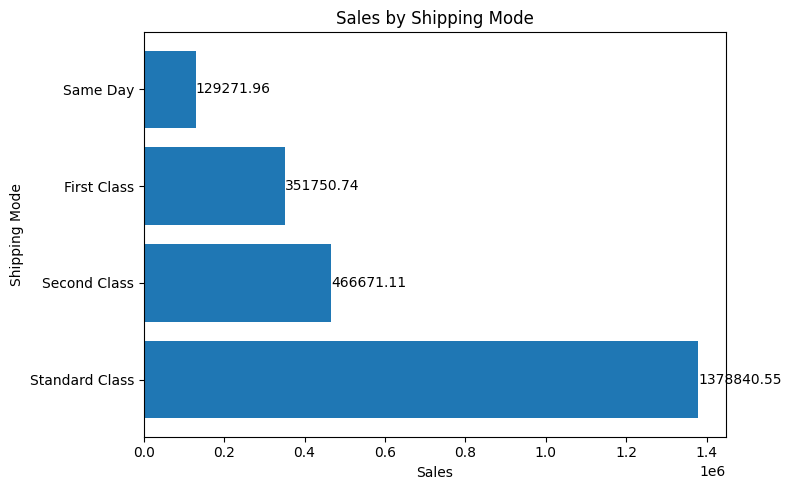

In [69]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    sales_shipping.index,
    sales_shipping.values
)

plt.title("Sales by Shipping Mode")
plt.xlabel("Sales")
plt.ylabel("Shipping Mode")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## Profit by Shipping Mode

### Business question:
Which shipping mode contributes the most profit?

In [72]:
profit_shipping = (
    df.groupby("ship_mode")["profit"]
      .sum()
      .sort_values(ascending=False)
)

profit_shipping

ship_mode
Standard Class    168161.2095
Second Class       58962.1329
First Class        49012.7242
Same Day           16160.7480
Name: profit, dtype: float64

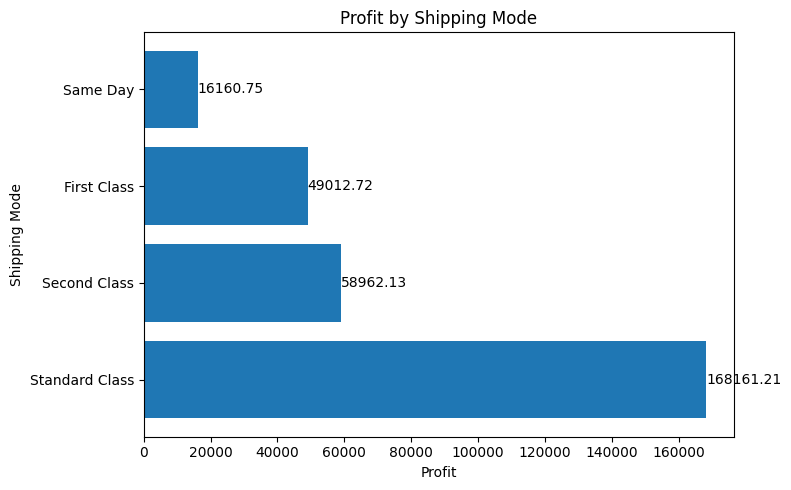

In [76]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    profit_shipping.index,
    profit_shipping.values
)

plt.title("Profit by Shipping Mode")
plt.xlabel("Profit")
plt.ylabel("Shipping Mode")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## Profit Margin by Shipping

### Business question:
Which shipping mode contributes the most profit margin?

In [78]:
profit_margin = (
    df.groupby("ship_mode")["profit_margin"]
      .mean()
      .sort_values(ascending=False)
)

profit_margin

ship_mode
Second Class      0.151421
Same Day          0.139499
First Class       0.115410
Standard Class    0.112952
Name: profit_margin, dtype: float64

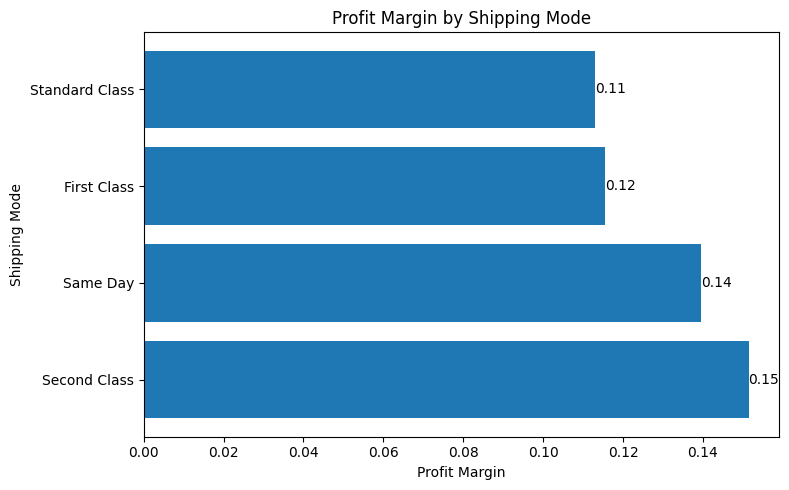

In [79]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    profit_margin.index,
    profit_margin.values
)

plt.title("Profit Margin by Shipping Mode")
plt.xlabel("Profit Margin")
plt.ylabel("Shipping Mode")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Business Question:
Does faster shipping actually improve profitability?

In [84]:
df.groupby("ship_mode")[["sales", "profit", "profit_margin"]].mean()

,sales,profit,profit_margin
ship_mode,,,
First Class,227.229158,31.661967,0.115410
Same Day,236.328985,29.544329,0.139499
Second Class,235.811577,29.793902,0.151421
Standard Class,225.300744,27.477322,0.112952


-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Shipping Analysis

### Objective
Analyze shipping performance to understand delivery times, compare shipping modes, identify operational inefficiencies, and determine whether shipping speed has any relationship with business performance.

## Shipping Time Distribution
### Business question:
How long do orders generally take to ship?

### Objective
Analyze the overall distribution of shipping times to understand typical delivery performance, identify the most common delivery duration, and detect any unusual shipping patterns that may indicate operational inefficiencies.

In [85]:
# Summary statistics for shipping time

shipping_stats = df["shipping_days"].describe()

shipping_stats

count    10194.000000
mean         3.961350
std          1.742829
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
Name: shipping_days, dtype: float64

In [86]:
print(f"Median Shipping Days : {df['shipping_days'].median():.2f}")
print(f"Mode Shipping Days   : {df['shipping_days'].mode().iloc[0]}")
print(f"Skewness             : {df['shipping_days'].skew():.2f}")

Median Shipping Days : 4.00
Mode Shipping Days   : 4
Skewness             : -0.41


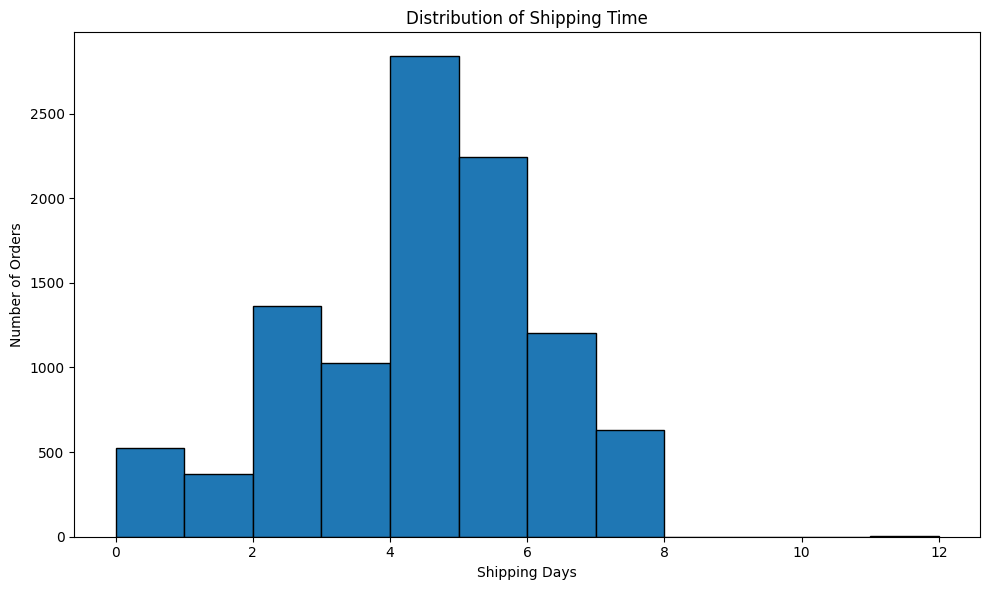

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df["shipping_days"],
    bins=range(
        int(df["shipping_days"].min()),
        int(df["shipping_days"].max()) + 2
    ),
    edgecolor="black"
)

plt.title("Distribution of Shipping Time")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Data Summary

Shipping time was analyzed using the engineered shipping_days feature across 10,194 orders.

### Key Observations

* The average shipping time is approximately 4 days, indicating a generally consistent delivery process.
* Both the median and mode are 4 days, suggesting that four-day delivery is the standard fulfillment duration for most orders.
* Shipping times are moderately concentrated between 3 and 6 days, where the majority of orders are delivered.
* The distribution exhibits a slight negative (left) skew (-0.41), indicating that a relatively small number of orders are delivered exceptionally quickly, while most deliveries remain clustered around the average.
* Very few orders require more than 8 days for delivery, with the maximum observed shipping time being 11 days, indicating that long delivery delays are uncommon.

### Business Interpretation

The company's logistics operations appear to be stable and predictable, with most customers receiving their orders within approximately four days. The close alignment between the mean, median, and mode indicates a well-controlled shipping process with limited variability.

The small number of extremely fast deliveries (0–1 days) likely represents special circumstances such as same-day fulfillment, local deliveries, or expedited shipments rather than the standard delivery process. Similarly, orders taking more than eight days are rare and should be reviewed individually to determine whether they resulted from inventory shortages, carrier delays, or other operational issues.

Overall, the shipping process demonstrates good operational consistency, providing a reliable foundation for evaluating the performance of different shipping modes in the next analysis.

### Recommendations

* Maintain the current logistics process, as the majority of deliveries are completed within a consistent four-day window.
* Investigate orders requiring more than 8 days to identify recurring operational bottlenecks or carrier-related issues.
* Review exceptionally fast deliveries to determine whether their practices can be replicated where operationally feasible.
* Benchmark individual shipping modes against this overall distribution to identify which services contribute most effectively to delivery performance.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Shipping Performance by Shipping Mode

### Objective

Compare the average shipping time across different shipping modes to identify which delivery methods are the fastest and whether each shipping option performs as expected.

In [88]:
shipping_mode_summary = (
    df.groupby("ship_mode")
      .agg(
          average_shipping_days=("shipping_days", "mean"),
          median_shipping_days=("shipping_days", "median"),
          total_orders=("shipping_days", "count")
      )
      .sort_values("average_shipping_days")
      .round(2)
)

shipping_mode_summary

,average_shipping_days,median_shipping_days,total_orders
ship_mode,,,
Same Day,0.04,0.0,547
First Class,2.18,2.0,1548
Second Class,3.24,3.0,1979
Standard Class,5.00,5.0,6120


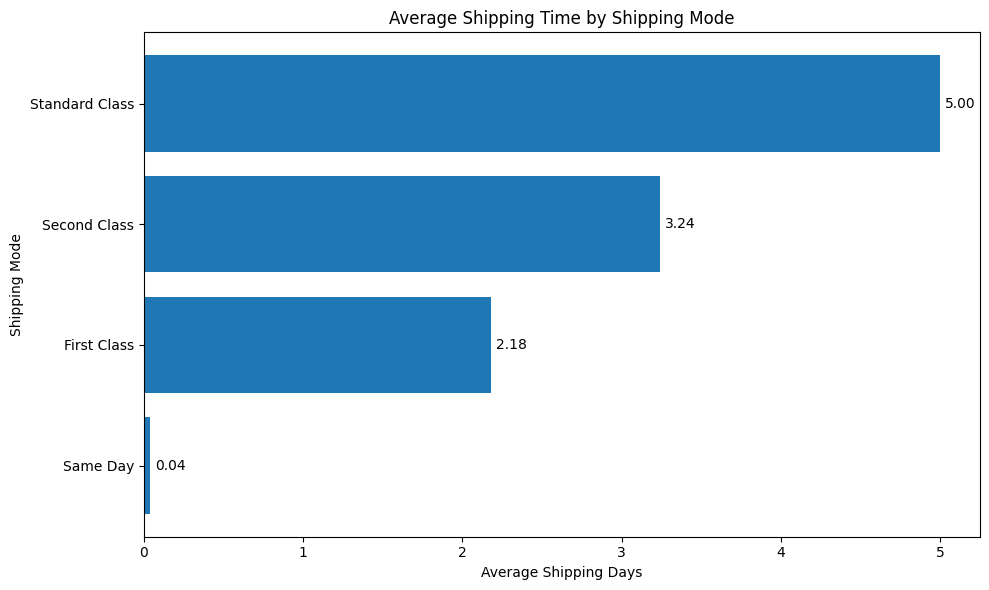

In [ ]:
import matplotlib.pyplot as plt #plotting the average shipping time by shipping mode using a horizontal bar chart

plt.figure(figsize=(10, 6))

bars = plt.barh(
    shipping_mode_summary.index,
    shipping_mode_summary["average_shipping_days"]
)

plt.title("Average Shipping Time by Shipping Mode")
plt.xlabel("Average Shipping Days")
plt.ylabel("Shipping Mode")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [90]:
shipping_mode_distribution = ( 
    df.groupby("ship_mode")["shipping_days"]
      .describe()
      .round(2)
)

shipping_mode_distribution

,count,mean,std,min,25%,50%,75%,max
ship_mode,,,,,,,,
First Class,1548.0,2.18,0.77,1.0,2.0,2.0,3.0,4.0
Same Day,547.0,0.04,0.21,0.0,0.0,0.0,0.0,1.0
Second Class,1979.0,3.24,1.19,1.0,2.0,3.0,4.0,5.0
Standard Class,6120.0,5.00,1.02,3.0,4.0,5.0,6.0,11.0


### Objective

Compare the average shipping time across different shipping modes to evaluate the efficiency of each delivery service and determine whether faster shipping options provide the expected operational advantage.

### Data Summary

Shipping performance was analyzed across the four available shipping modes by calculating the average shipping time, median shipping time, and total number of orders processed under each service.

### Key Observations

* Same Day shipping is the fastest delivery option, with an average shipping time of only 0.04 days, indicating that nearly all orders are fulfilled on the same day.
* First Class shipments require approximately 2.18 days on average, making it the fastest standard shipping service after Same Day delivery.
* Second Class orders are delivered in approximately 3.24 days, positioning it as an intermediate shipping option between First Class and Standard Class.
* Standard Class has the longest average delivery time at 5 days and accounts for the largest share of orders (6,120 orders, approximately 60% of all shipments).
* The average shipping time increases consistently from Same Day to Standard Class, demonstrating that each shipping service performs according to its intended service level.
* The median shipping time closely matches the average for every shipping mode, indicating consistent delivery performance with limited variability.

### Business Interpretation

The shipping process appears to be well aligned with the company's service-level offerings. Faster shipping options consistently achieve shorter delivery times, while Standard Class serves as the primary fulfillment method for the majority of customers.

The dominance of Standard Class suggests that customers are generally willing to accept longer delivery times, likely in exchange for lower shipping costs. Meanwhile, expedited services such as Same Day and First Class effectively provide significantly faster deliveries for customers requiring urgent fulfillment.

The close agreement between average and median shipping times indicates that delivery performance is stable across all shipping modes, with few extreme delays affecting overall service quality.

### Recommendations

* Continue prioritizing Standard Class as the primary shipping option due to its high adoption and consistent delivery performance.
* Promote First Class and Same Day shipping for customers with time-sensitive orders, emphasizing their significantly shorter delivery times.
* Regularly monitor shipping performance to ensure each service continues to meet its expected delivery standards.
* Investigate the relatively small number of delayed shipments within each shipping mode to identify opportunities for further improving operational efficiency.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Shipping Mode Usage

### Business question:
Which shipping methods are used most frequently?

### Objective

Analyze the distribution of orders across different shipping modes to understand customer preferences and identify the most frequently used shipping service.

In [91]:
shipping_mode_usage = (
    df["ship_mode"]
    .value_counts()
    .rename_axis("ship_mode")
    .reset_index(name="total_orders")
)

shipping_mode_usage["percentage"] = (
    shipping_mode_usage["total_orders"]
    / shipping_mode_usage["total_orders"].sum()
    * 100
).round(2)

shipping_mode_usage

,ship_mode,total_orders,percentage
0,Standard Class,6120,60.04
1,Second Class,1979,19.41
2,First Class,1548,15.19
3,Same Day,547,5.37


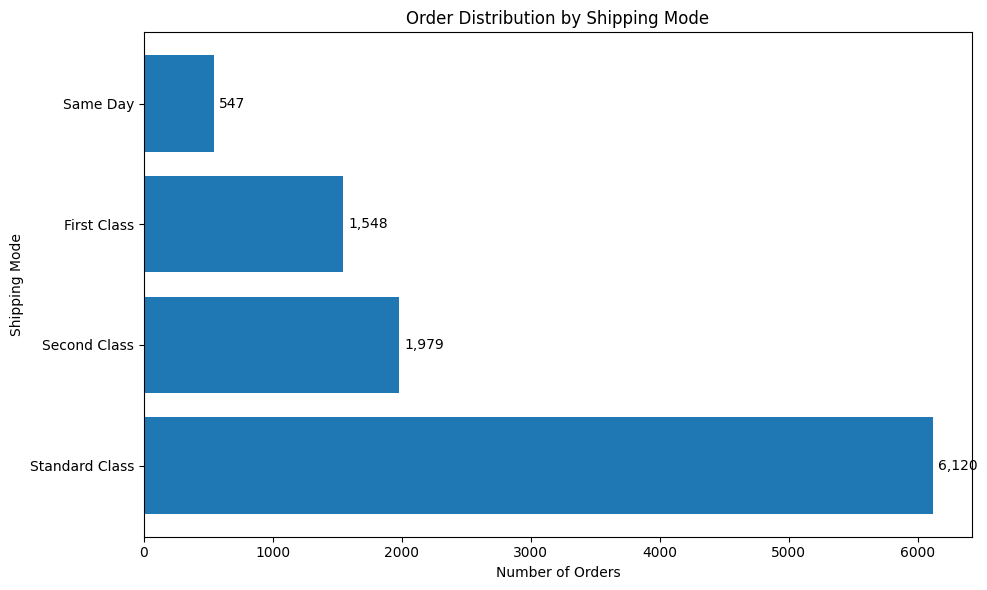

In [92]:
import matplotlib.pyplot as plt #plotting the distribution of orders by shipping mode using a horizontal bar chart

plt.figure(figsize=(10, 6))

bars = plt.barh(
    shipping_mode_usage["ship_mode"],
    shipping_mode_usage["total_orders"]
)

plt.title("Order Distribution by Shipping Mode")
plt.xlabel("Number of Orders")
plt.ylabel("Shipping Mode")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 40,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Objective

Analyze how orders are distributed across different shipping modes to understand customer shipping preferences and identify the company's primary delivery service.

### Data Summary

Order distribution was calculated for each shipping mode by counting the total number of orders and determining its percentage contribution to overall shipments.

### Key Observations

* Standard Class is the dominant shipping option, accounting for 6,120 orders (60.04%), making it the preferred delivery method for the majority of customers.
* Second Class is the second most frequently used shipping mode, representing 19.41% of all shipments.
* First Class accounts for 15.19% of total orders, indicating moderate demand for expedited delivery.
* Same Day shipping is the least utilized option, contributing only 5.37% of total shipments.
* Nearly three out of every five orders are fulfilled through Standard Class, highlighting a strong customer preference for standard delivery services.

### Business Interpretation

The order distribution suggests that most customers prioritize standard shipping over premium delivery options, likely balancing delivery time against shipping cost. While expedited services provide faster fulfillment, they are selected far less frequently, indicating that rapid delivery is required only for a relatively small proportion of orders.

The heavy reliance on Standard Class also implies that maintaining its operational efficiency is essential, as any disruptions in this shipping mode would affect the majority of customers.

### Recommendations

* Continue optimizing Standard Class operations, as improvements in this service will benefit the largest customer segment.
* Promote expedited shipping options for customers with time-sensitive purchases where appropriate.
* Monitor demand trends across shipping modes to ensure logistics resources remain aligned with customer preferences.
* Periodically evaluate pricing and service levels of premium shipping options to encourage adoption where beneficial.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Shipping Time vs Profit
### Business question:
Does longer shipping correlate with profitability?

### Objective

Analyze whether shipping time has any relationship with profitability by comparing the average sales, average profit, profit margin, and order count across different shipping durations.

In [93]:
shipping_profit_summary = (
    df.groupby("shipping_days")
      .agg(
          average_sales=("sales", "mean"),
          average_profit=("profit", "mean"),
          profit_margin=("profit_margin", "mean"),
          total_orders=("order_id", "count")
      )
      .round(2)
      .reset_index()
)

shipping_profit_summary

,shipping_days,average_sales,average_profit,profit_margin,total_orders
0,0,240.57,29.93,0.14,523
1,1,184.21,20.44,0.13,369
2,2,272.46,39.55,0.13,1361
3,3,200.52,26.60,0.15,1025
4,4,225.42,25.28,0.10,2838
5,5,227.87,27.85,0.12,2243
6,6,199.61,27.65,0.13,1204
7,7,262.35,32.51,0.11,629
8,11,99.12,35.41,0.36,2


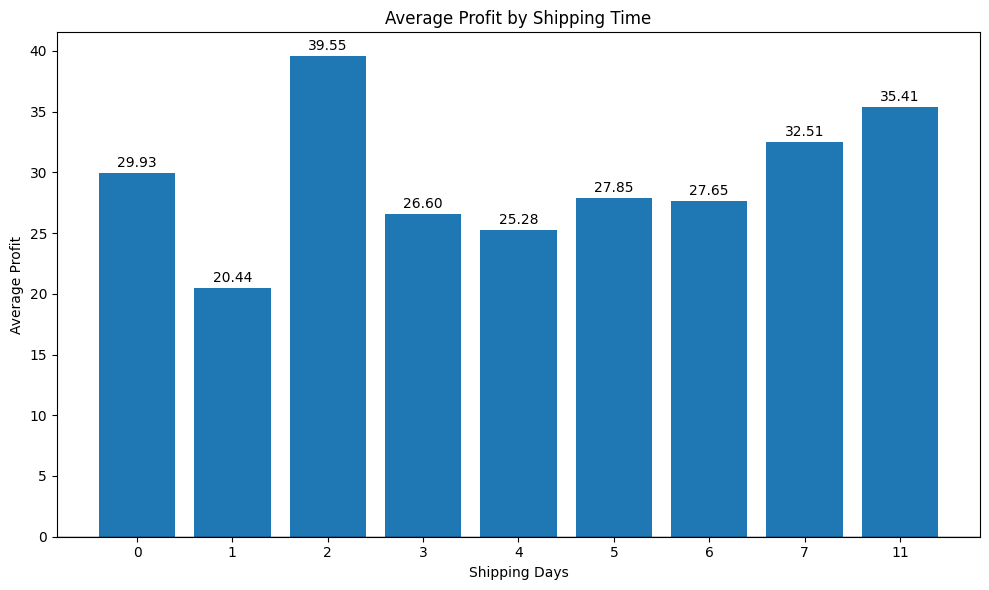

In [ ]:
import matplotlib.pyplot as plt #plotting the average profit by shipping time using a bar chart

plt.figure(figsize=(10, 6))

bars = plt.bar(
    shipping_profit_summary["shipping_days"].astype(str),
    shipping_profit_summary["average_profit"]
)

plt.title("Average Profit by Shipping Time")
plt.xlabel("Shipping Days")
plt.ylabel("Average Profit")

plt.axhline(0, color="black", linewidth=1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (0.5 if height >= 0 else -1.2),
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [96]:
correlation = df["shipping_days"].corr(df["profit"]) #Calculating the correlation between shipping days and profit to understand the relationship between these two variables.

print(f"Correlation between Shipping Days and Profit: {correlation:.3f}")

Correlation between Shipping Days and Profit: -0.004


### Objective

Analyze whether shipping duration has any meaningful relationship with profitability by comparing average profit across different shipping times and measuring the correlation between shipping days and profit.

### Data Summary

Orders were grouped by shipping_days to calculate average sales, average profit, average profit margin, and total order count. In addition, the Pearson correlation coefficient between shipping time and profit was computed.

### Key Observations

* The correlation between shipping time and profit is -0.004, indicating virtually no linear relationship between delivery duration and profitability.
* Average profit varies across shipping durations; however, the differences do not follow a consistent increasing or decreasing trend.
* Orders delivered in 2 days have the highest average profit (39.55), while 1-day shipments have the lowest (20.44).
* The apparent profitability of 11-day shipments is not meaningful because it is based on only 2 orders, making it statistically unreliable.
* The majority of orders are concentrated between 4 and 6 shipping days, where average profit remains relatively stable.

### Business Interpretation

Shipping duration alone does not appear to influence profitability. Instead, profit is likely driven by factors such as product mix, discount levels, customer segments, and order composition rather than the number of days required for delivery.

This suggests that improving delivery speed should primarily be viewed as a customer service initiative rather than a direct strategy for increasing profit.

### Recommendations

* Continue optimizing shipping operations to improve customer experience rather than expecting direct financial gains.
* Focus profitability improvement efforts on pricing, discount management, and product portfolio optimization.
* Avoid drawing conclusions from shipping durations with very small sample sizes.
* Monitor shipping performance as an operational KPI while evaluating profitability using broader business drivers.

-------------------------------------------------------------------------------------------------------------------------------------------------------

# Final EDA Summary

### Objective

Summarize the key business insights obtained from the Exploratory Data Analysis and highlight the major findings that will guide subsequent SQL analysis and business recommendations.

## Summary of Key Findings

### Sales Performance

* Sales exhibited an overall upward trend over the observed period, indicating sustained business growth despite periodic fluctuations.
* Monthly sales showed noticeable seasonality, suggesting recurring demand patterns throughout the year.

### Regional Performance

* The West region generated the highest sales and profit, making it the strongest performing market.
The Central region consistently underperformed in profitability, indicating potential operational or pricing challenges.

### Product Performance
* Technology was the most profitable product category.
* Copiers generated the highest profit among all sub-categories.
* Tables, Bookcases, and Supplies consistently produced losses despite contributing to overall sales.

### Customer Analysis

* Revenue and profitability were concentrated among a relatively small group of customers, although the dataset did not strictly follow the classic 80/20 Pareto Principle.
* High-revenue customers were not always the most profitable, demonstrating that customer value should be evaluated using multiple performance metrics.
* Purchase frequency, sales, and profitability represented distinct dimensions of customer behavior.

### Discount Analysis
* Most orders were sold either without discounts or with a standard 20% discount.
* Discounts showed a weak negative relationship with profitability.
* Average profit became negative once discounts exceeded 20%.
* Orders with discounts of 45% and above were consistently loss-making.

### Shipping Analysis
* Average delivery time was approximately 4 days, with most shipments completed between 3 and 6 days.
* Shipping modes performed according to their intended service levels, with Same Day being the fastest and Standard Class serving the majority of orders.
* Standard Class accounted for approximately 60% of all shipments.
* Shipping duration showed virtually no relationship with profitability (correlation ≈ -0.004), indicating that delivery speed does not directly influence profit.

## Overall Business Conclusion

The analysis indicates that the company's profitability is primarily influenced by product mix, discount strategy, and regional performance rather than logistics or delivery speed. While shipping operations appear efficient and consistent, significant opportunities for improving profitability exist through better discount management, addressing loss-making product lines, and strengthening performance in underperforming regions.